In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
df = pd.read_csv('covid_19_data.csv')

In [3]:
df.shape

(306429, 8)

In [4]:
df.columns.to_list()

['SNo',
 'ObservationDate',
 'Province/State',
 'Country/Region',
 'Last Update',
 'Confirmed',
 'Deaths',
 'Recovered']

In [5]:
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,01/22/2020,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
1,2,01/22/2020,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0
2,3,01/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0
3,4,01/22/2020,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0
4,5,01/22/2020,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0


In [6]:
df.tail()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
306424,306425,05/29/2021,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0
306425,306426,05/29/2021,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0
306426,306427,05/29/2021,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0
306427,306428,05/29/2021,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0
306428,306429,05/29/2021,Zuid-Holland,Netherlands,2021-05-30 04:20:55,391559.0,4252.0,0.0


In [7]:
df.sample(5)

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
173637,173638,12/07/2020,Calabria,Italy,2021-04-02 15:13:53,18712.0,353.0,8018.0
142098,142099,10/26/2020,Nevada,US,2021-04-02 15:13:53,96178.0,1749.0,0.0
242967,242968,03/08/2021,NaN,Congo (Kinshasa),2021-04-02 15:13:53,26627.0,712.0,22432.0
72478,72479,07/25/2020,Gilgit-Baltistan,Pakistan,2021-04-02 15:13:53,1952.0,47.0,1559.0
83248,83249,08/08/2020,Sormland,Sweden,2021-04-02 15:13:53,2399.0,253.0,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SNo              306429 non-null  int64  
 1   ObservationDate  306429 non-null  object 
 2   Province/State   228326 non-null  object 
 3   Country/Region   306429 non-null  object 
 4   Last Update      306429 non-null  object 
 5   Confirmed        306429 non-null  float64
 6   Deaths           306429 non-null  float64
 7   Recovered        306429 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 18.7+ MB


In [9]:
df.isna().sum()/len(df)*100

SNo                 0.000000
ObservationDate     0.000000
Province/State     25.488123
Country/Region      0.000000
Last Update         0.000000
Confirmed           0.000000
Deaths              0.000000
Recovered           0.000000
dtype: float64

In [10]:
(df['Province/State'].value_counts())

Province/State
Unknown                         4123
Amazonas                        1109
Diamond Princess cruise ship     924
Grand Princess                   882
Punjab                           708
                                ... 
Charlotte County, FL               1
Collin County, TX                  1
Cherokee County, GA                1
Dadar Nagar Haveli                 1
Chicago                            1
Name: count, Length: 736, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,SNo,Confirmed,Deaths,Recovered
count,306429.000000,3.064290e+05,306429.000000,3.064290e+05
mean,153215.000000,8.567091e+04,2036.403268,5.042029e+04
std,88458.577156,2.775516e+05,6410.938048,2.015124e+05
min,1.000000,-3.028440e+05,-178.000000,-8.544050e+05
25%,76608.000000,1.042000e+03,13.000000,1.100000e+01
50%,153215.000000,1.037500e+04,192.000000,1.751000e+03
75%,229822.000000,5.075200e+04,1322.000000,2.027000e+04
max,306429.000000,5.863138e+06,112385.000000,6.399531e+06


In [13]:
df.corr(numeric_only=True)

,SNo,Confirmed,Deaths,Recovered
SNo,1.000000,0.237319,0.197038,0.190511
Confirmed,0.237319,1.000000,0.888416,0.633479
Deaths,0.197038,0.888416,1.000000,0.538416
Recovered,0.190511,0.633479,0.538416,1.000000


In [14]:
df.cov(numeric_only=True)

,SNo,Confirmed,Deaths,Recovered
SNo,7.824920e+09,5.826617e+09,1.117405e+08,3.395961e+09
Confirmed,5.826617e+09,7.703489e+10,1.580817e+09,3.543056e+10
Deaths,1.117405e+08,1.580817e+09,4.110013e+07,6.955715e+08
Recovered,3.395961e+09,3.543056e+10,6.955715e+08,4.060727e+10


In [15]:
df.cov(numeric_only=True)

,SNo,Confirmed,Deaths,Recovered
SNo,7.824920e+09,5.826617e+09,1.117405e+08,3.395961e+09
Confirmed,5.826617e+09,7.703489e+10,1.580817e+09,3.543056e+10
Deaths,1.117405e+08,1.580817e+09,4.110013e+07,6.955715e+08
Recovered,3.395961e+09,3.543056e+10,6.955715e+08,4.060727e+10


In [16]:
df.kurt(numeric_only=True)

SNo           -1.200000
Confirmed    108.874196
Deaths        88.286892
Recovered    174.419642
dtype: float64

In [17]:
df.skew(numeric_only=True)

SNo          7.724573e-17
Confirmed    8.768377e+00
Deaths       7.942417e+00
Recovered    1.069409e+01
dtype: float64

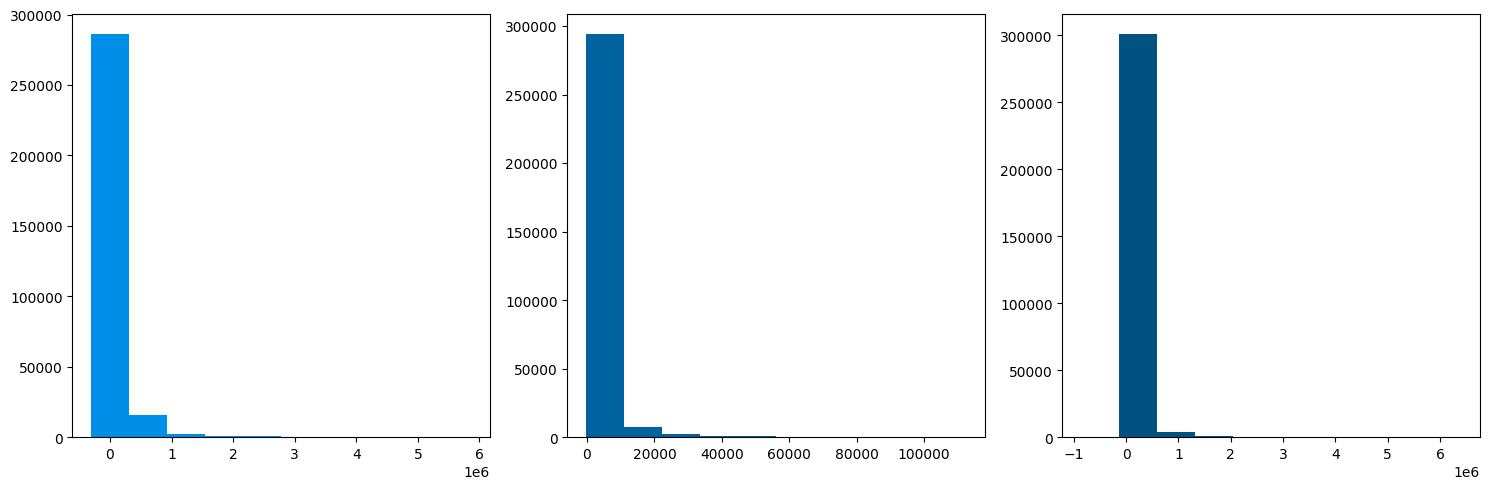

In [18]:
fig = plt.figure(figsize=(15,5))

gsp = gridspec.GridSpec(
                            nrows = 1,
                            ncols = 3,
                            figure = fig,
                            height_ratios=[1],
                            width_ratios=[1,1,1]
)

ax1 = fig.add_subplot(gsp[0:1,0:1])
ax2 = fig.add_subplot(gsp[0:1,1:2])
ax3 = fig.add_subplot(gsp[0:1,2:])

ax1.hist(df['Confirmed'],color="#008FE8")
ax2.hist(df['Deaths'],color="#00629F")
ax3.hist(df['Recovered'],color="#025183")

plt.tight_layout()
plt.show()

In [19]:
df['ObservationDate'].str.replace(r'\d','X',regex=True).value_counts() 
# To make sure everything is in same format before parsing /  converting

ObservationDate
XX/XX/XXXX    306429
Name: count, dtype: int64

In [20]:
df['ObservationDate'] = pd.to_datetime(df['ObservationDate'] ,errors='raise')

In [21]:
df['ObservationDate_Year'] = df['ObservationDate'].dt.year
df['ObservationDate_Month'] = df['ObservationDate'].dt.month
df['ObservationDate_Day'] = df['ObservationDate'].dt.day

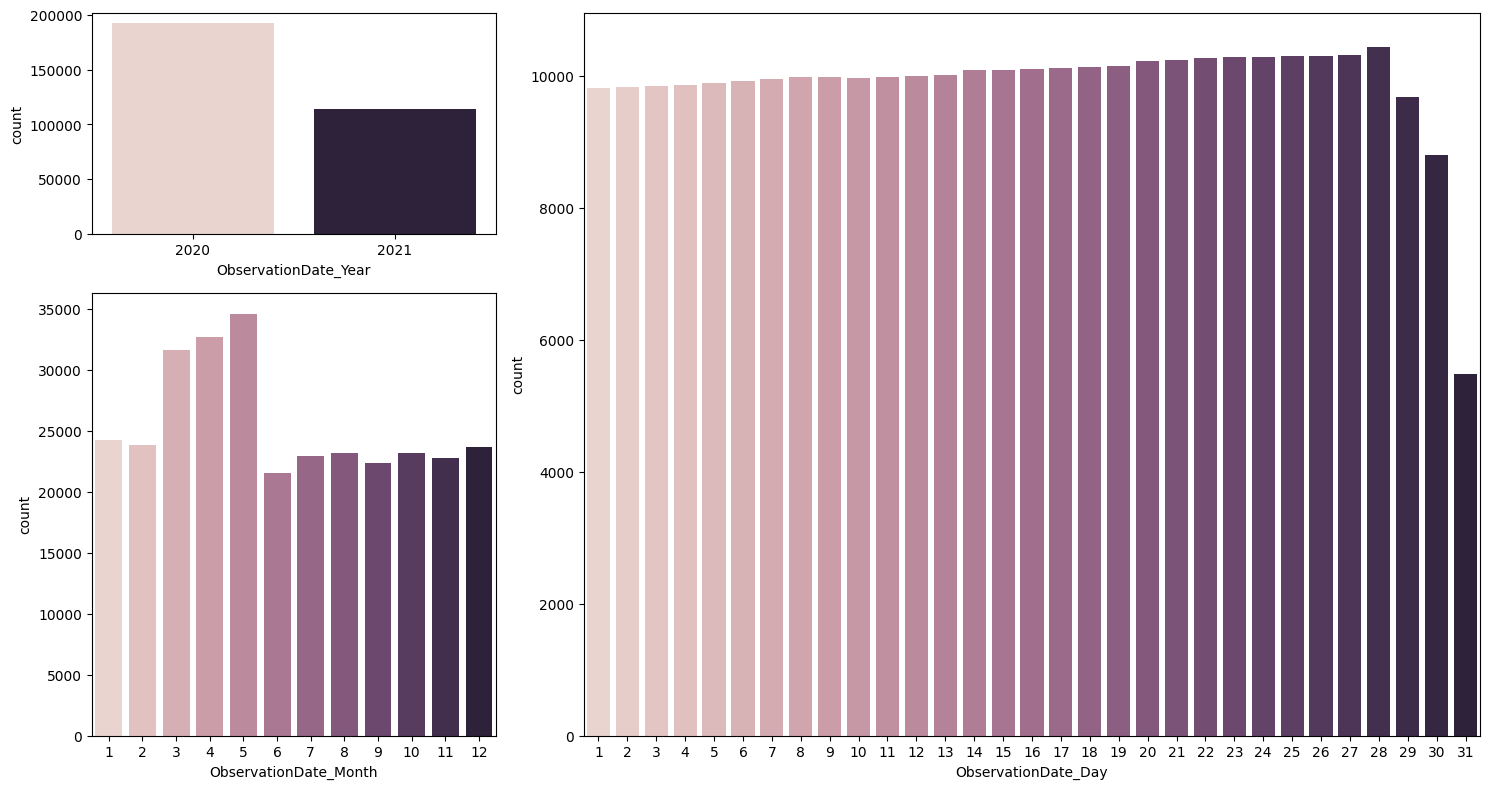

In [22]:
fig = plt.figure(figsize=(15,8))

gsp = gridspec.GridSpec(
                            nrows = 2,
                            ncols = 3,
                            figure = fig,
                            height_ratios=[1,2],
                            width_ratios=[1,1,1]
)

ax1 = fig.add_subplot(gsp[0:1,0:1])
ax2 = fig.add_subplot(gsp[1:2,0:1])
ax3 = fig.add_subplot(gsp[0:,1:])

sns.countplot(
    data = df,
    x = 'ObservationDate_Year',
    hue = 'ObservationDate_Year',
    ax = ax1,
    legend=False
)

sns.countplot(
    data = df,
    x = 'ObservationDate_Month',
    hue = 'ObservationDate_Month',
    ax = ax2,
    legend=False
)

sns.countplot(
    data = df,
    x = 'ObservationDate_Day',
    hue = 'ObservationDate_Day',
    ax = ax3,
    legend=False
)

plt.tight_layout()
plt.show()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   SNo                    306429 non-null  int64         
 1   ObservationDate        306429 non-null  datetime64[ns]
 2   Province/State         228326 non-null  object        
 3   Country/Region         306429 non-null  object        
 4   Last Update            306429 non-null  object        
 5   Confirmed              306429 non-null  float64       
 6   Deaths                 306429 non-null  float64       
 7   Recovered              306429 non-null  float64       
 8   ObservationDate_Year   306429 non-null  int32         
 9   ObservationDate_Month  306429 non-null  int32         
 10  ObservationDate_Day    306429 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(3)
memory usage: 22.2+ MB


In [24]:
# df.groupby(['Country/Region'])['Province/State'].value_counts()

In [25]:
df.head()

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
0,1,2020-01-22,Anhui,Mainland China,1/22/2020 17:00,1.0,0.0,0.0,2020,1,22
1,2,2020-01-22,Beijing,Mainland China,1/22/2020 17:00,14.0,0.0,0.0,2020,1,22
2,3,2020-01-22,Chongqing,Mainland China,1/22/2020 17:00,6.0,0.0,0.0,2020,1,22
3,4,2020-01-22,Fujian,Mainland China,1/22/2020 17:00,1.0,0.0,0.0,2020,1,22
4,5,2020-01-22,Gansu,Mainland China,1/22/2020 17:00,0.0,0.0,0.0,2020,1,22


In [26]:
df['Last Update'].str.replace(r'\d','X',regex=True).value_counts()
# These are the various formats in which data is stored in the column
# We need to extract different info accordingly

Last Update
XXXX-XX-XX XX:XX:XX    296475
XXXX-XX-XXTXX:XX:XX      7155
X/X/XX X:XX              2217
X/XX/XX XX:XX             409
X/XX/XXXX XX:XX           108
X/X/XXXX XX:XX             30
X/X/XXXX X:XX              26
X/XX/XXXX X:XX              9
Name: count, dtype: int64

In [27]:
pd.to_datetime(df['Last Update'],dayfirst=False, errors='coerce',format='mixed') 
# The magic , the messiah for me


0        2020-01-22 17:00:00
1        2020-01-22 17:00:00
2        2020-01-22 17:00:00
3        2020-01-22 17:00:00
4        2020-01-22 17:00:00
                 ...        
306424   2021-05-30 04:20:55
306425   2021-05-30 04:20:55
306426   2021-05-30 04:20:55
306427   2021-05-30 04:20:55
306428   2021-05-30 04:20:55
Name: Last Update, Length: 306429, dtype: datetime64[ns]

In [28]:
df['Last Update'] = pd.to_datetime(df['Last Update'],dayfirst=False, errors='coerce',format='mixed') 

In [29]:
df['Last Update'].isna().sum()

np.int64(0)

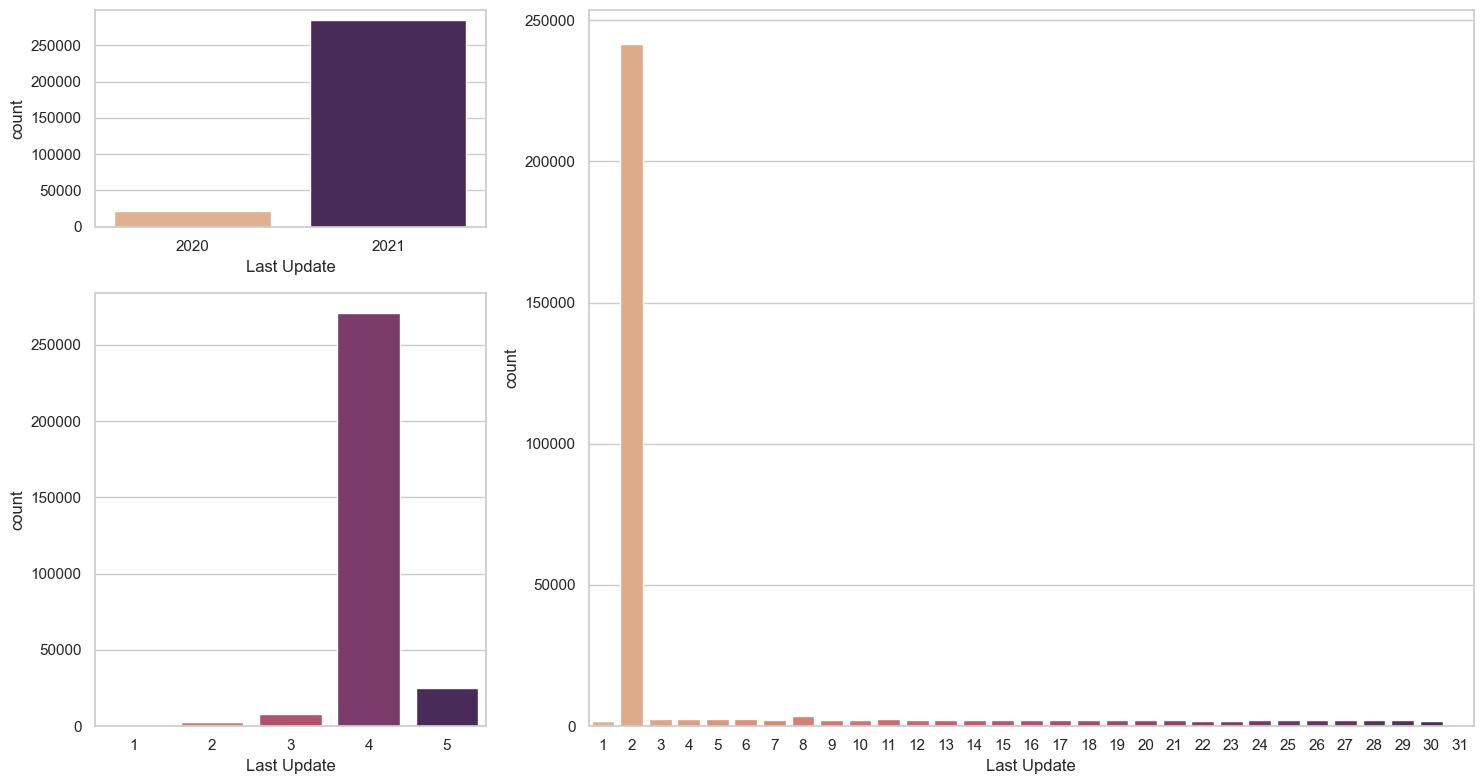

In [30]:
fig = plt.figure(figsize=(15,8))

sns.set_theme(style='whitegrid')

gsp = gridspec.GridSpec(
                            nrows = 2,
                            ncols = 3,
                            figure = fig,
                            height_ratios=[1,2],
                            width_ratios=[1,1,1]
)

ax1 = fig.add_subplot(gsp[0:1,0:1])
ax2 = fig.add_subplot(gsp[1:2,0:1])
ax3 = fig.add_subplot(gsp[0:,1:])

sns.countplot(
    data = df,
    x = df['Last Update'].dt.year,
    hue = df['Last Update'].dt.year,
    palette = 'flare',
    ax = ax1,
    legend=False
)

sns.countplot(
    data = df,
    x = df['Last Update'].dt.month,
    hue = df['Last Update'].dt.month,
    palette = 'flare',
    ax = ax2,
    legend=False
)

sns.countplot(
    data = df,
    x = df['Last Update'].dt.day,
    hue = df['Last Update'].dt.day,
    palette = 'flare',
    ax = ax3,
    legend=False
)

plt.tight_layout()
plt.show()

In [31]:
df.sample(3)

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
224865,224866,2021-02-12,Cusco,Peru,2021-04-02 15:13:53,31330.0,653.0,0.0,2021,2,12
281174,281175,2021-04-26,Yukon,Canada,2021-04-27 04:20:52,81.0,2.0,79.0,2021,4,26
88476,88477,2020-08-15,South Dakota,US,2021-04-02 15:13:53,10118.0,152.0,0.0,2020,8,15


In [32]:
df.groupby(['Country/Region'])['Province/State'].value_counts()

Country/Region  Province/State    
Australia       New South Wales       489
                Victoria              489
                Queensland            486
                South Australia       484
                Western Australia     456
                                     ... 
Ukraine         Vinnytsia Oblast      363
                Volyn Oblast          363
                Zakarpattia Oblast    363
                Zaporizhia Oblast     363
                Zhytomyr Oblast       363
Name: count, Length: 759, dtype: int64

<Axes: >

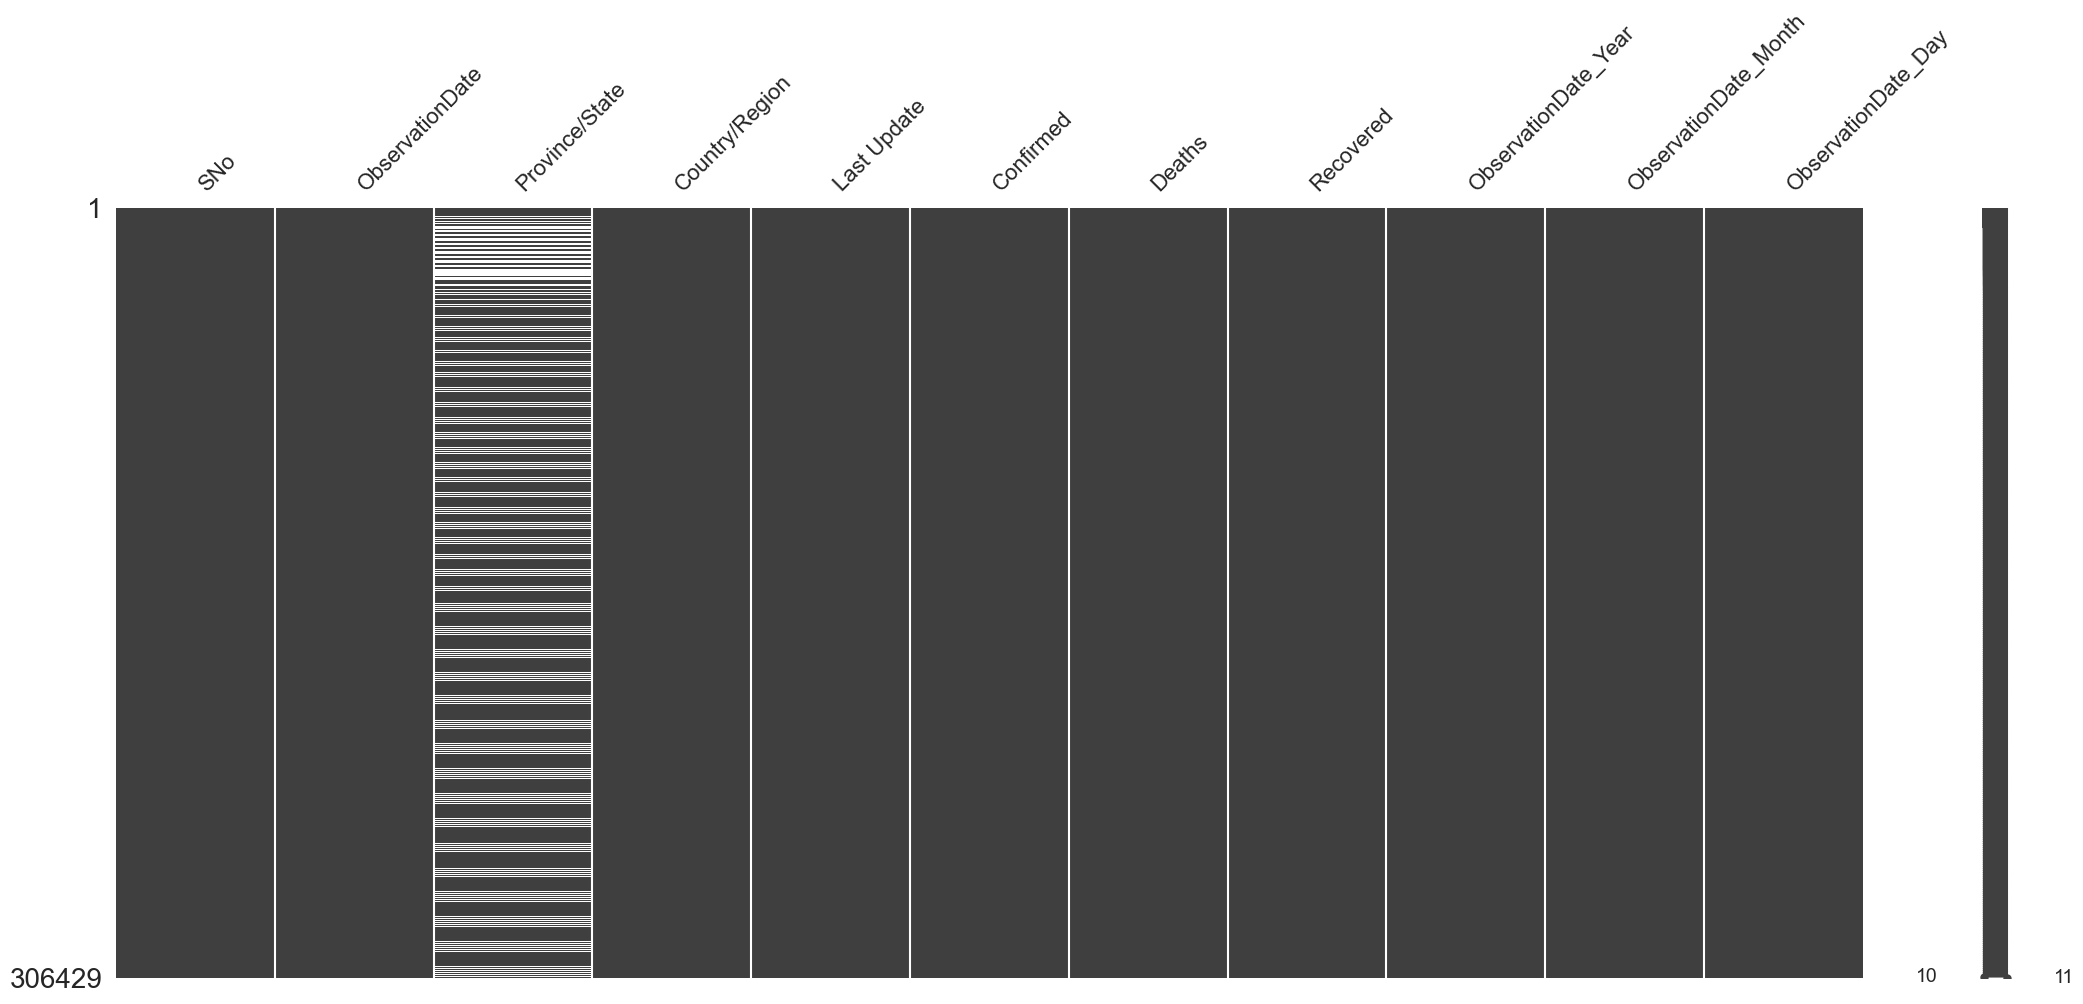

In [33]:
import missingno as msno
msno.matrix(df=df)

In [34]:
df['Province/State'] = df.groupby(['Country/Region'])['Province/State'].ffill()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306429 entries, 0 to 306428
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   SNo                    306429 non-null  int64         
 1   ObservationDate        306429 non-null  datetime64[ns]
 2   Province/State         230398 non-null  object        
 3   Country/Region         306429 non-null  object        
 4   Last Update            306429 non-null  datetime64[ns]
 5   Confirmed              306429 non-null  float64       
 6   Deaths                 306429 non-null  float64       
 7   Recovered              306429 non-null  float64       
 8   ObservationDate_Year   306429 non-null  int32         
 9   ObservationDate_Month  306429 non-null  int32         
 10  ObservationDate_Day    306429 non-null  int32         
dtypes: datetime64[ns](2), float64(3), int32(3), int64(1), object(2)
memory usage: 22.2+ MB


In [36]:
df.describe()

,SNo,ObservationDate,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
count,306429.000000,306429,306429,3.064290e+05,306429.000000,3.064290e+05,306429.000000,306429.000000,306429.000000
mean,153215.000000,2020-11-06 01:54:54.146441728,2021-03-11 01:14:17.227314944,8.567091e+04,2036.403268,5.042029e+04,2020.371907,6.239905,15.824237
min,1.000000,2020-01-22 00:00:00,2020-01-22 17:00:00,-3.028440e+05,-178.000000,-8.544050e+05,2020.000000,1.000000,1.000000
25%,76608.000000,2020-07-30 00:00:00,2021-04-02 15:13:53,1.042000e+03,13.000000,1.100000e+01,2020.000000,3.000000,8.000000
50%,153215.000000,2020-11-10 00:00:00,2021-04-02 15:13:53,1.037500e+04,192.000000,1.751000e+03,2020.000000,6.000000,16.000000
75%,229822.000000,2021-02-18 00:00:00,2021-04-02 15:13:53,5.075200e+04,1322.000000,2.027000e+04,2021.000000,9.000000,23.000000
max,306429.000000,2021-05-29 00:00:00,2021-05-30 04:20:55,5.863138e+06,112385.000000,6.399531e+06,2021.000000,12.000000,31.000000
std,88458.577156,NaN,NaN,2.775516e+05,6410.938048,2.015124e+05,0.483314,3.392173,8.766587


In [37]:
df[df['Confirmed'] < 0 | (df['Deaths'] < 0) | (df['Recovered'] < 0 ) ]

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
118363,118364,2020-09-24,Unknown,Colombia,2021-04-02 15:13:53,0.0,-178.0,-12684.0,2020,9,24
141534,141535,2020-10-25,Unknown,Colombia,2021-04-02 15:13:53,0.0,-154.0,-8072.0,2020,10,25
145277,145278,2020-10-30,Unknown,Colombia,2021-04-02 15:13:53,0.0,505.0,-854405.0,2020,10,30
147524,147525,2020-11-02,Unknown,Colombia,2021-04-02 15:13:53,-302844.0,0.0,0.0,2020,11,2


In [38]:
df['Confirmed'].value_counts()

Confirmed
0.0         4741
1.0         2439
13.0        1237
18.0        1047
3.0          934
            ... 
423117.0       1
97830.0        1
266414.0       1
327112.0       1
75296.0        1
Name: count, Length: 107146, dtype: int64

In [39]:
df['Recovered'].value_counts()

Recovered
0.0         68529
1.0          2189
13.0         1120
2.0          1042
18.0          971
            ...  
225696.0        1
71624.0         1
152231.0        1
120100.0        1
286758.0        1
Name: count, Length: 74541, dtype: int64

In [40]:
df['Deaths'].value_counts()

Deaths
0.0         32417
1.0          9799
2.0          6921
3.0          6107
6.0          4153
            ...  
26201.0         1
112385.0        1
10713.0         1
20837.0         1
13615.0         1
Name: count, Length: 20089, dtype: int64

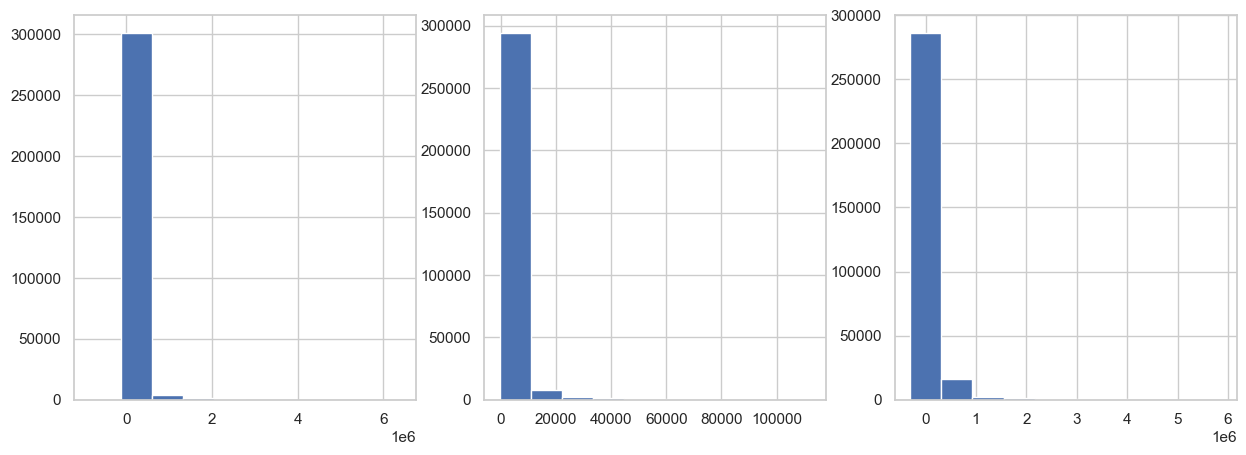

In [41]:
plt.figure(figsize=(15,5))
for i,x in zip(range(1,4),['Recovered','Deaths','Confirmed']):
    plt.subplot(1,3,i)
    plt.hist(
                data = df,
                x = x
            )
plt.show()

In [42]:
Q1 = df['Confirmed'].quantile(.25)
Q3 = df['Confirmed'].quantile(.75)
IQR = Q1 - Q3
lower_outlier_range_cnf = IQR - 1.5*Q1
upper_outlier_range_cnf = IQR + 1.5*Q1
df[(df['Confirmed'] < lower_outlier_range_cnf) | (df['Confirmed'] > upper_outlier_range_cnf) ]

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
0,1,2020-01-22,Anhui,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
1,2,2020-01-22,Beijing,Mainland China,2020-01-22 17:00:00,14.0,0.0,0.0,2020,1,22
2,3,2020-01-22,Chongqing,Mainland China,2020-01-22 17:00:00,6.0,0.0,0.0,2020,1,22
3,4,2020-01-22,Fujian,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
4,5,2020-01-22,Gansu,Mainland China,2020-01-22 17:00:00,0.0,0.0,0.0,2020,1,22
...,...,...,...,...,...,...,...,...,...,...,...
306424,306425,2021-05-29,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0,2021,5,29
306425,306426,2021-05-29,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0,2021,5,29
306426,306427,2021-05-29,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0,2021,5,29
306427,306428,2021-05-29,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0,2021,5,29


In [43]:
Q1 = df['Deaths'].quantile(.25)
Q3 = df['Deaths'].quantile(.75)
IQR = Q1 - Q3
lower_outlier_range_dt = IQR - 1.5*Q1
upper_outlier_range_dt = IQR + 1.5*Q1
df[(df['Deaths'] < lower_outlier_range_dt) | (df['Deaths'] > upper_outlier_range_dt) ]

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
0,1,2020-01-22,Anhui,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
1,2,2020-01-22,Beijing,Mainland China,2020-01-22 17:00:00,14.0,0.0,0.0,2020,1,22
2,3,2020-01-22,Chongqing,Mainland China,2020-01-22 17:00:00,6.0,0.0,0.0,2020,1,22
3,4,2020-01-22,Fujian,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
4,5,2020-01-22,Gansu,Mainland China,2020-01-22 17:00:00,0.0,0.0,0.0,2020,1,22
...,...,...,...,...,...,...,...,...,...,...,...
306424,306425,2021-05-29,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0,2021,5,29
306425,306426,2021-05-29,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0,2021,5,29
306426,306427,2021-05-29,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0,2021,5,29
306427,306428,2021-05-29,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0,2021,5,29


In [44]:
Q1 = df['Recovered'].quantile(.25)
Q3 = df['Recovered'].quantile(.75)
IQR = Q1 - Q3
lower_outlier_range_rc = IQR - 1.5*Q1
upper_outlier_range_rc = IQR + 1.5*Q1
df[(df['Recovered'] < lower_outlier_range_rc) | (df['Recovered'] > upper_outlier_range_rc) ]

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
0,1,2020-01-22,Anhui,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
1,2,2020-01-22,Beijing,Mainland China,2020-01-22 17:00:00,14.0,0.0,0.0,2020,1,22
2,3,2020-01-22,Chongqing,Mainland China,2020-01-22 17:00:00,6.0,0.0,0.0,2020,1,22
3,4,2020-01-22,Fujian,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
4,5,2020-01-22,Gansu,Mainland China,2020-01-22 17:00:00,0.0,0.0,0.0,2020,1,22
...,...,...,...,...,...,...,...,...,...,...,...
306424,306425,2021-05-29,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0,2021,5,29
306425,306426,2021-05-29,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0,2021,5,29
306426,306427,2021-05-29,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0,2021,5,29
306427,306428,2021-05-29,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0,2021,5,29


In [45]:
# I see a pattern

In [46]:
df[
   (df['Recovered'] < lower_outlier_range_rc)  | 
   (df['Recovered'] > upper_outlier_range_rc)  |
   (df['Confirmed'] < lower_outlier_range_cnf) | 
   (df['Confirmed'] > upper_outlier_range_cnf) |
   (df['Deaths'] < lower_outlier_range_dt)     | 
   (df['Deaths'] > upper_outlier_range_dt)
]
# See ? The same 11 columns

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
0,1,2020-01-22,Anhui,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
1,2,2020-01-22,Beijing,Mainland China,2020-01-22 17:00:00,14.0,0.0,0.0,2020,1,22
2,3,2020-01-22,Chongqing,Mainland China,2020-01-22 17:00:00,6.0,0.0,0.0,2020,1,22
3,4,2020-01-22,Fujian,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
4,5,2020-01-22,Gansu,Mainland China,2020-01-22 17:00:00,0.0,0.0,0.0,2020,1,22
...,...,...,...,...,...,...,...,...,...,...,...
306424,306425,2021-05-29,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0,2021,5,29
306425,306426,2021-05-29,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0,2021,5,29
306426,306427,2021-05-29,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0,2021,5,29
306427,306428,2021-05-29,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0,2021,5,29


In [ ]:
df[
   (df['Recovered'] < lower_outlier_range_rc)  | 
   (df['Recovered'] > upper_outlier_range_rc)  |
   (df['Confirmed'] < lower_outlier_range_cnf) | 
   (df['Confirmed'] > upper_outlier_range_cnf) |
   (df['Deaths'] < lower_outlier_range_dt)     | 
   (df['Deaths'] > upper_outlier_range_dt)     |
   (df['Confirmed'] < 0) | (df['Deaths'] < 0) | (df['Recovered'] < 0 ) 
]
# Amazing 😛

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered,ObservationDate_Year,ObservationDate_Month,ObservationDate_Day
0,1,2020-01-22,Anhui,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
1,2,2020-01-22,Beijing,Mainland China,2020-01-22 17:00:00,14.0,0.0,0.0,2020,1,22
2,3,2020-01-22,Chongqing,Mainland China,2020-01-22 17:00:00,6.0,0.0,0.0,2020,1,22
3,4,2020-01-22,Fujian,Mainland China,2020-01-22 17:00:00,1.0,0.0,0.0,2020,1,22
4,5,2020-01-22,Gansu,Mainland China,2020-01-22 17:00:00,0.0,0.0,0.0,2020,1,22
...,...,...,...,...,...,...,...,...,...,...,...
306424,306425,2021-05-29,Zaporizhia Oblast,Ukraine,2021-05-30 04:20:55,102641.0,2335.0,95289.0,2021,5,29
306425,306426,2021-05-29,Zeeland,Netherlands,2021-05-30 04:20:55,29147.0,245.0,0.0,2021,5,29
306426,306427,2021-05-29,Zhejiang,Mainland China,2021-05-30 04:20:55,1364.0,1.0,1324.0,2021,5,29
306427,306428,2021-05-29,Zhytomyr Oblast,Ukraine,2021-05-30 04:20:55,87550.0,1738.0,83790.0,2021,5,29
